In [4]:
from IPython.display import Image
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error as MSE


# Supervise larning under the hood

- In supervised learning you make assumptions that there is a mapping f between labels and features 
- We can express this by y = f(x)
![title](images/1.png)
- f which is here shown in red here is an unknown function that you want to determine , In reality data generation is always accompanied with randomnes or noise like the blue points shown here


# Goals of supervised leaning 
- Find a model F : f̂ ≈ f
- f̂ can be logistic regression , Descision Tree , Neural Network
- Discard noise as much as possible
- End goal : f̂ should achieve a low predictive error on unseen datasets

# Difficulties in Approximating f̂
- Overfitting f̂(x) fits the training set noise.
- Underfitting f̂ is not flexible enough to approximate f̂ 


# Overfitting
- When a mode; overfits the training set its predictive power on unseen dataset is pretty low. (shown below)
- The model clearly memorized the noise present in the training set
- Such model achieves a low training set error and high test error 

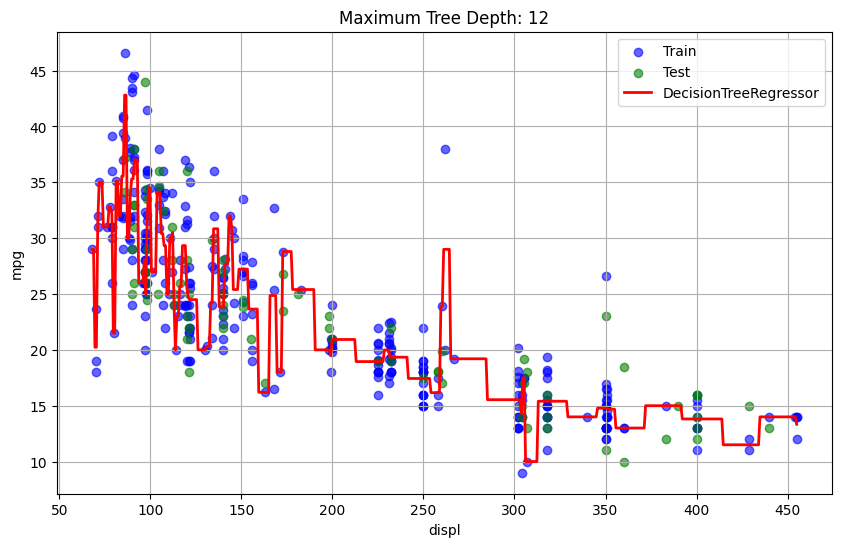

In [5]:
df = pd.read_csv(r"/Users/apple/Documents Local/Mubashir Code/ML/Machine Learning with Tree-Based Models in Python/Classification and Regression Trees/Regression/output_data.csv")
df.head()
df = df.drop(["car_name","model_year","origin"],axis=1)

# train-test split
X = df['displacement'].values   
y = df['mpg'].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Train Descion Tree
dt = DecisionTreeRegressor(max_depth=12, random_state=42)
X_train = X_train.reshape(-1,1)
dt.fit(X_train, y_train)

X_range = np.linspace(X.min(), X.max(), 500).reshape(-1, 1)
y_pred = dt.predict(X_range)

plt.figure(figsize=(10, 6))

# Scatter points
plt.scatter(X_train, y_train, color='blue', alpha=0.6, label='Train')
plt.scatter(X_test, y_test, color='green', alpha=0.6, label='Test')

# Prediction line
plt.plot(X_range, y_pred, color='red', linewidth=2, label='DecisionTreeRegressor')

# Labels & title
plt.xlabel('displ')
plt.ylabel('mpg')
plt.title('Maximum Tree Depth: 12')

plt.legend()
plt.grid(True)
plt.show()


# Underfitting
- When a model underfits the data , like the regression tree whose predictions are shown here in red , the training set error is roughly equal to the test set error,
- However both errors are relatively high . now the trained model isnt flexible enough to capture the complex dependency between features and labels . 


# Genralization Error

- The generalization error of a model tells you how much it generalizes on unseen data 
-  It can be decomposed into 3 terms 
- **f̂ = bias^2 + variance + irreducible error** 
- irreducable error where the irreducible error is the error contribution of noise

# Bias
- Bias : error term that tells you on average , how much **f̂** not equal to **F**
- To illustrate this consider the high bias model is not flexible enough to approximate the true function **f** shown in red .
- High bias models lead to underfitting



![title](images/2.png)


# Variance 
- Variance : Tells you how much f̂ is inconsistent over different training sets
- Consider the hgh variance model below shown here in black ; in this case that follows the training data points so closelt that it missed the true function shown in red . High variance models lead to overfitting

![title](images/3.png)

# Model Complexity
- Model Complexity : sets the flexibility of f̂
- Example : Increasing the maximum-tree-depth increases the complexity of a desision tree

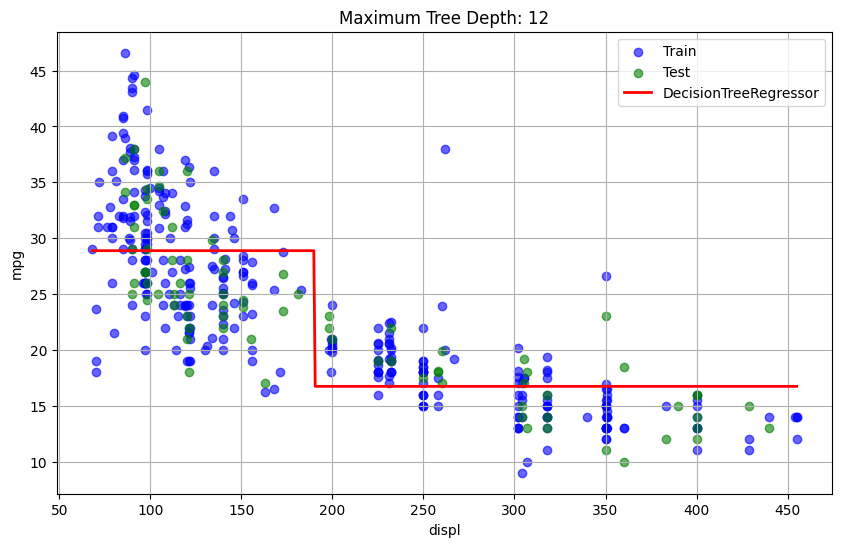

In [6]:
df = pd.read_csv(r"/Users/apple/Documents Local/Mubashir Code/ML/Machine Learning with Tree-Based Models in Python/Classification and Regression Trees/Regression/output_data.csv")
df.head()
df = df.drop(["car_name","model_year","origin"],axis=1)

# train-test split
X = df['displacement'].values   
y = df['mpg'].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Train Descion Tree
dt = DecisionTreeRegressor(max_depth=1, random_state=42)
X_train = X_train.reshape(-1,1)
dt.fit(X_train, y_train)

X_range = np.linspace(X.min(), X.max(), 500).reshape(-1, 1)
y_pred = dt.predict(X_range)

plt.figure(figsize=(10, 6))

# Scatter points
plt.scatter(X_train, y_train, color='blue', alpha=0.6, label='Train')
plt.scatter(X_test, y_test, color='green', alpha=0.6, label='Test')

# Prediction line
plt.plot(X_range, y_pred, color='red', linewidth=2, label='DecisionTreeRegressor')

# Labels & title
plt.xlabel('displ')
plt.ylabel('mpg')
plt.title('Maximum Tree Depth: 12')

plt.legend()
plt.grid(True)
plt.show()


# Bias Variance Tradeoff

![title](images/4.png)


- the diagram here shows how the best model complexity corresponfs to the lowest generalization error 
- When the model complexity increases , the variance increases while the bias decreases
- Conversely , when model complexity decreases , variance decreases and bias increases .
- Your goal is to find the model complexity that achieves the lowest generalization error
- Since this error is the sum of three terms with the irreducible error being constant , you need to find a balance between bias and variance because as one increases the other decreases . This is known as the bias-variance trade-off

# Bias variance tradeoff : A visual explanation

![title](images/5.png)



# Estimating the Generalization Error
### Problem
- How do we estimate the generalization error of a model ?
- Cannot be directly done because 
    - **f̂** is unknown
    - usually you only have one dataset
    - noise is unpredictable
    - we dont have access to the error term due to noise
### Solution 
- Split the data to training and test sets
- fit **f̂** to the training set
- evaluate the error of **f̂** on unseen test set
- generaliztion error of **f̂** ≈ test set error of **f̂**

## Better Model Evaluation with Cross Validation
- Test set should not be touched until we are confident about **f̂** performance
- Evaluating **f̂** on training set: biased estimate , **f̂** has already seen all training points
- Solution -> Cross Validation (CV)
    - K Fold CV 
    - Hold - Out cv

![title](images/6.png)


### CV error is computed by finding the mean

# Diagnose Variance Problems
- if **f̂** suffers from high variance : CV error of **f̂** > training set error of **f̂**
- **f̂** is said to overfit training data . To remedy overfitting :
    - decrease model complexity 
    - for ex : decrease max depth , increase min samples per leaf
    - gather more data 

# Diagnose Bias Problems
- if **f̂** suffers from high bias : CV error of **f̂** is approximately equal to training set of **f̂** >> desired error
- **f̂** is said to underfit the training set . To remedy underfitting :
    - Increase model's complexity 
    - for example increase max depth , decrease min samples per leaf 
    - gather more relevant features 


# KFold Validation in sickit Learn on the Auto Dataset

# Summary 
- The CV MSE can be determined as the mean of MSE_CV . Finally you can use the function MSE to evaluate the train and test set MSE . Given that the Train MSE is less than CV MSE we can deduce that dt overfits the training set and that it suffers from high variance . Notice how the CV and test set errors are roughly equal

In [11]:
# Set seed for reproducibly 
SEED = 123

# Split the 70% training and 30% test set 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED
)
X_train = X_train.reshape(-1,1)
X_test = X_test.reshape(-1,1)

# Instantiate a decision tree regressor 
dt = DecisionTreeRegressor(
    max_depth=4,
    min_samples_leaf=0.14,
    random_state=SEED
)

# Evaluate the list of MSE obtained by 10 Fold CV
# Set n jobs to -1 in order to exploit all CPU cores in computation
MSE_CV = - cross_val_score(dt,X_train,y_train,cv=10,scoring='neg_mean_squared_error',n_jobs=-1)

# Fit the dt to training set 
dt.fit(X_train,y_train)

# Predict the labels of training set 
y_predict_train = dt.predict(X_train)

# Predcit the labels of test set 
y_predict_test = dt.predict(X_test)

# CV MSE
print('CV MSE: {:.2f}'.format(MSE_CV.mean()))

# Training set MSE
print('Train MSE: {:.2f}'.format(MSE(y_train,y_predict_train)))

# Test Set 
print('Test MSE: {:.2f}'.format(MSE(y_test,y_predict_test)))

CV MSE: 18.78
Train MSE: 17.55
Test MSE: 20.22
